In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

# -----------------------------
# 1. Load complete pairwise datasets from multiple AOIs
# -----------------------------

root_dir = Path("/home/roger/sat-bundleadjust_github")

aoi_ids = ["OMA_042", "OMA_132", "OMA_134", "OMA_144", "OMA_163", "OMA_172", "OMA_176", "OMA_203", "OMA_211", "OMA_230", 
         "OMA_244", "OMA_247", "OMA_248", "OMA_251", "OMA_258", "OMA_269", "OMA_278", "OMA_281", "OMA_287", "OMA_315",
         "OMA_329", "OMA_331", "OMA_342", "OMA_353", "OMA_355", "OMA_367", "OMA_381", "OMA_383", "OMA_389", "OMA_391"]

downsampled=False
suffix = "" if downsampled else "_wo_downsample"
csv_paths = [
    root_dir / "eval" / "superpoint_matching" / aoi_id / f"pairwise_image_similarities{suffix}.csv"
    for aoi_id in aoi_ids
]

similarity_cols = [
    "ssim",
    "dinov2",
    "dinov3_sat",
    "clip_rn50",
    "clip_vit_b32",
    "clip_vit_l14",
]

required_cols = [
    "image_1_index",
    "image_2_index",
    "image_1_basename",
    "image_2_basename",
    "superpoint_lightglue_num_matches",
] + similarity_cols

dfs = []

for aoi_id, csv_path in zip(aoi_ids, csv_paths):
    if not csv_path.exists():
        print(f"WARNING: CSV not found for AOI '{aoi_id}': {csv_path}")
        continue

    aoi_df = pd.read_csv(csv_path)

    missing_cols = [col for col in required_cols if col not in aoi_df.columns]
    if missing_cols:
        raise ValueError(
            f"Missing expected columns for AOI '{aoi_id}' in {csv_path}: {missing_cols}"
        )

    aoi_df.insert(0, "aoi_id", aoi_id)

    aoi_df = aoi_df.rename(
        columns={
            "superpoint_lightglue_num_matches": "sift_matches"
        }
    )

    aoi_df["pair_key"] = (
        aoi_df["aoi_id"].astype(str)
        + "__"
        + aoi_df["image_1_index"].astype(str)
        + "_"
        + aoi_df["image_2_index"].astype(str)
    )

    dfs.append(aoi_df)

if len(dfs) == 0:
    raise RuntimeError("No AOI CSV files were loaded. Check aoi_ids and root_dir.")

df = pd.concat(dfs, ignore_index=True)

if "pair_id" not in df.columns:
    df.insert(0, "pair_id", np.arange(len(df)))

# -----------------------------
# 2. Ensure numeric types
# -----------------------------

numeric_cols = ["image_1_index", "image_2_index", "sift_matches"] + similarity_cols

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# 3. Validate raw similarities
# -----------------------------

for col in similarity_cols:
    invalid_mask = df[col].isna() | ~df[col].between(0, 1)

    if invalid_mask.any():
        n_invalid = int(invalid_mask.sum())
        min_val = df[col].min(skipna=True)
        max_val = df[col].max(skipna=True)

        bad_by_aoi = (
            df.loc[invalid_mask]
            .groupby("aoi_id")
            .size()
            .sort_values(ascending=False)
        )

        print(
            f"WARNING: column '{col}' has {n_invalid} invalid similarity values "
            f"outside [0, 1] or NaN. min={min_val}, max={max_val}"
        )
        print("Invalid values by AOI:")
        print(bad_by_aoi)

valid_similarity_mask = np.ones(len(df), dtype=bool)

for col in similarity_cols:
    valid_similarity_mask &= df[col].notna() & df[col].between(0, 1)

df_valid = df.loc[valid_similarity_mask].copy()

# Keep raw values available for inspection if needed.
df_raw = df.copy()

# -----------------------------
# 4. Ordinary min-max normalize descriptors in place
# -----------------------------

for col in similarity_cols:
    valid = df[col].dropna()

    if len(valid) == 0:
        print(f"WARNING: cannot min-max normalize '{col}' because all values are NaN")
        df[col] = np.nan
        continue

    lo = valid.min()
    hi = valid.max()

    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        print(
            f"WARNING: cannot min-max normalize '{col}' because range is invalid: "
            f"min={lo}, max={hi}"
        )
        df[col] = np.nan
        continue

    df[col] = (df[col] - lo) / (hi - lo)

    print(
        f"{col}: raw min={lo:.4f}, "
        f"raw max={hi:.4f}, "
        f"normalized min={df[col].min(skipna=True):.4f}, "
        f"normalized max={df[col].max(skipna=True):.4f}"
    )

# Keep using the original metric names downstream.
metrics = similarity_cols

print("\nUsing in-place min-max normalized metrics:")
print(metrics)

# -----------------------------
# 5. Summary
# -----------------------------

print(f"\nLoaded {len(df)} image pairs from {df['aoi_id'].nunique()} AOIs")
print(f"Rows with valid raw similarities: {len(df_valid)} / {len(df)}")
print(f"Pairs with nonzero matches: {int((df['sift_matches'] > 0).sum())} / {len(df)}")
print(f"Total matches: {int(df['sift_matches'].fillna(0).sum())}")

print("\nRows by AOI:")
print(df.groupby("aoi_id").size().sort_values(ascending=False))

print("\nNormalized descriptor ranges:")
for col in metrics:
    print(
        col,
        "min=", df[col].min(skipna=True),
        "max=", df[col].max(skipna=True),
        "q01=", df[col].quantile(0.01),
        "q99=", df[col].quantile(0.99),
    )

df.head()

ssim: raw min=0.0892, raw max=0.7126, normalized min=0.0000, normalized max=1.0000
dinov2: raw min=0.6964, raw max=0.9953, normalized min=0.0000, normalized max=1.0000
dinov3_sat: raw min=0.5884, raw max=0.9912, normalized min=0.0000, normalized max=1.0000
clip_rn50: raw min=0.7641, raw max=0.9959, normalized min=0.0000, normalized max=1.0000
clip_vit_b32: raw min=0.8272, raw max=0.9972, normalized min=0.0000, normalized max=1.0000
clip_vit_l14: raw min=0.8559, raw max=0.9969, normalized min=0.0000, normalized max=1.0000

Using in-place min-max normalized metrics:
['ssim', 'dinov2', 'dinov3_sat', 'clip_rn50', 'clip_vit_b32', 'clip_vit_l14']

Loaded 24258 image pairs from 30 AOIs
Rows with valid raw similarities: 24258 / 24258
Pairs with nonzero matches: 24253 / 24258
Total matches: 4967460

Rows by AOI:
aoi_id
OMA_203    903
OMA_251    861
OMA_248    861
OMA_353    861
OMA_287    861
OMA_331    861
OMA_342    861
OMA_381    861
OMA_391    861
OMA_258    820
OMA_211    820
OMA_176    82

,pair_id,aoi_id,image_1_index,image_2_index,image_1_basename,image_2_basename,sift_matches,ssim,dinov2,dinov3_sat,clip_rn50,clip_vit_b32,clip_vit_l14,pair_key
0,0,OMA_042,0,1,OMA_042_001_RGB.tif,OMA_042_002_RGB.tif,221,0.234384,0.969254,0.649248,0.961333,0.933482,0.862550,OMA_042__0_1
1,1,OMA_042,0,2,OMA_042_001_RGB.tif,OMA_042_003_RGB.tif,253,0.265824,0.890490,0.567241,0.914199,0.907182,0.873651,OMA_042__0_2
2,2,OMA_042,0,3,OMA_042_001_RGB.tif,OMA_042_004_RGB.tif,334,0.173916,0.922163,0.737725,0.960563,0.845841,0.928512,OMA_042__0_3
3,3,OMA_042,0,4,OMA_042_001_RGB.tif,OMA_042_006_RGB.tif,204,0.187882,0.902478,0.506861,0.950813,0.933353,0.925009,OMA_042__0_4
4,4,OMA_042,0,5,OMA_042_001_RGB.tif,OMA_042_007_RGB.tif,683,0.190570,0.896119,0.421130,0.909670,0.965349,0.884981,OMA_042__0_5


In [2]:
# -----------------------------
# 2. Correlate normalized similarity metrics with SuperPoint+LightGlue match counts
# -----------------------------

target_col = "sift_matches"

# metrics should already be defined in the loading cell as:
# metrics = ["ssim", "dinov2", "dinov3_sat", "clip_rn50", "clip_vit_b32", "clip_vit_l14"]
# and these columns should now contain in-place min-max normalized values.

missing_metrics = [m for m in metrics if m not in df.columns]
if missing_metrics:
    raise ValueError(f"Missing metric columns: {missing_metrics}")

if target_col not in df.columns:
    raise ValueError(f"Missing target column: {target_col}")

rows = []

for metric in metrics:
    valid = df[[metric, target_col]].copy()

    valid[metric] = pd.to_numeric(valid[metric], errors="coerce")
    valid[target_col] = pd.to_numeric(valid[target_col], errors="coerce")

    valid = valid.dropna()

    # Keep only valid normalized similarities
    invalid_mask = ~valid[metric].between(0, 1)
    if invalid_mask.any():
        print(
            f"WARNING: excluding {int(invalid_mask.sum())} rows for '{metric}' "
            "because normalized similarity is outside [0, 1]"
        )
        valid = valid.loc[~invalid_mask].copy()

    if len(valid) < 2:
        spearman_r = np.nan
        pearson_r = np.nan
        reason = "fewer than 2 valid rows"
    elif valid[metric].nunique() < 2:
        spearman_r = np.nan
        pearson_r = np.nan
        reason = "metric is constant"
    elif valid[target_col].nunique() < 2:
        spearman_r = np.nan
        pearson_r = np.nan
        reason = "match count is constant"
    else:
        spearman_r, _ = spearmanr(valid[metric], valid[target_col])
        pearson_r, _ = pearsonr(valid[metric], valid[target_col])
        reason = "ok"

    rows.append({
        "metric": metric,
        "spearman": spearman_r,
        "pearson": pearson_r,
        "n_pairs": len(valid),
        "metric_min": valid[metric].min() if len(valid) else np.nan,
        "metric_max": valid[metric].max() if len(valid) else np.nan,
        "target_nonzero": int((valid[target_col] > 0).sum()) if len(valid) else 0,
        "reason": reason,
    })

corr_df = pd.DataFrame(rows).sort_values(
    "spearman",
    ascending=False,
    na_position="last",
)

corr_df

,metric,spearman,pearson,n_pairs,metric_min,metric_max,target_nonzero,reason
1,dinov2,0.716340,0.495679,24258,0.0,1.0,24253,ok
3,clip_rn50,0.693885,0.464451,24258,0.0,1.0,24253,ok
5,clip_vit_l14,0.689321,0.510930,24258,0.0,1.0,24253,ok
4,clip_vit_b32,0.642227,0.440129,24258,0.0,1.0,24253,ok
2,dinov3_sat,0.590225,0.490864,24258,0.0,1.0,24253,ok
0,ssim,0.477684,0.378883,24258,0.0,1.0,24253,ok


### Plot 1: correlation bar chart

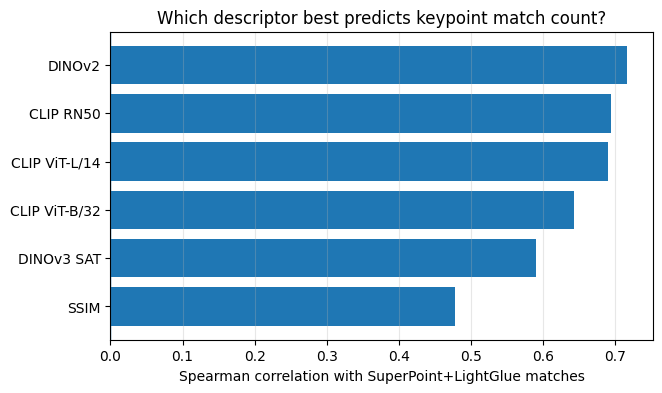

In [3]:
pretty_metric_names = {
    "ssim": "SSIM",
    "dinov2": "DINOv2",
    "dinov3_sat": "DINOv3 SAT",
    "clip_rn50": "CLIP RN50",
    "clip_vit_b32": "CLIP ViT-B/32",
    "clip_vit_l14": "CLIP ViT-L/14",
}

plot_corr_df = corr_df.copy()
plot_corr_df = plot_corr_df.dropna(subset=["spearman"])
plot_corr_df["metric_label"] = (
    plot_corr_df["metric"]
    .map(pretty_metric_names)
    .fillna(plot_corr_df["metric"])
)

plt.figure(figsize=(7, 4))
plt.barh(plot_corr_df["metric_label"], plot_corr_df["spearman"])
plt.axvline(0, linewidth=1)

plt.xlabel("Spearman correlation with SuperPoint+LightGlue matches")
plt.title("Which descriptor best predicts keypoint match count?")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

### Plot 2: scatter plots against SIFT matches

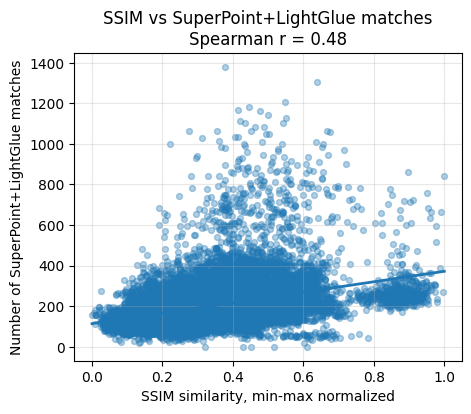

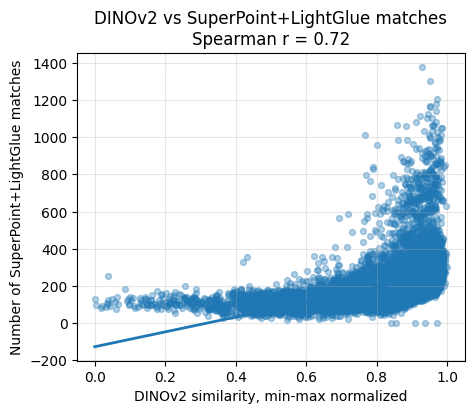

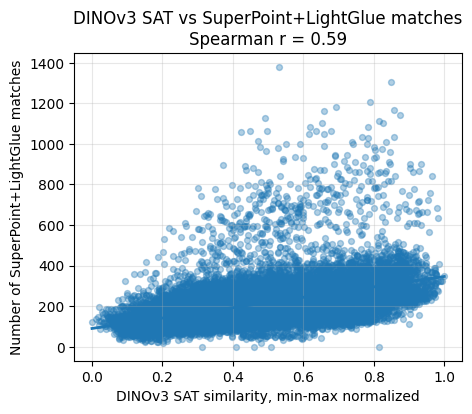

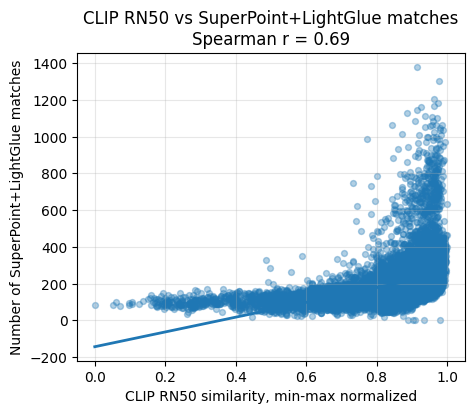

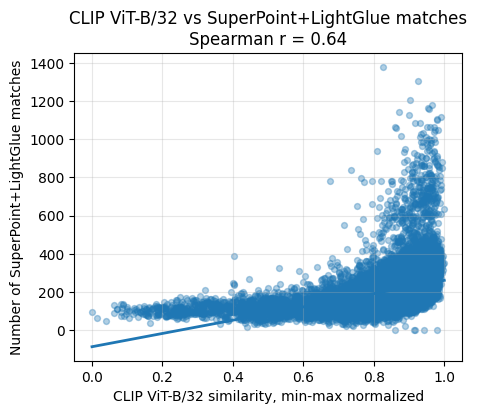

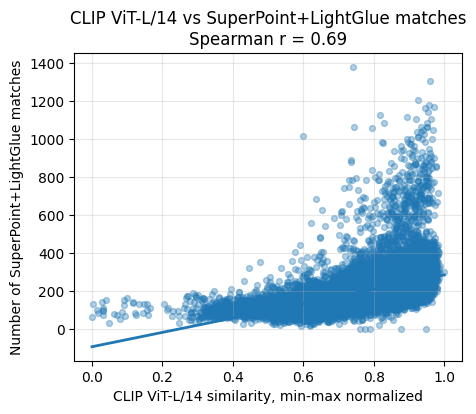

In [4]:
pretty_metric_names = {
    "ssim": "SSIM",
    "dinov2": "DINOv2",
    "dinov3_sat": "DINOv3 SAT",
    "clip_rn50": "CLIP RN50",
    "clip_vit_b32": "CLIP ViT-B/32",
    "clip_vit_l14": "CLIP ViT-L/14",
}

target_col = "sift_matches"

for metric in metrics:
    valid = df[[metric, target_col]].copy()

    valid[metric] = pd.to_numeric(valid[metric], errors="coerce")
    valid[target_col] = pd.to_numeric(valid[target_col], errors="coerce")

    valid = valid.dropna()
    valid = valid[valid[metric].between(0, 1)]

    if len(valid) < 2:
        print(f"WARNING: skipping {metric}: fewer than 2 valid rows")
        continue

    if valid[metric].nunique() < 2:
        print(f"WARNING: skipping {metric}: metric is constant")
        continue

    if valid[target_col].nunique() < 2:
        print(f"WARNING: skipping {metric}: match count is constant")
        continue

    r, _ = spearmanr(valid[metric], valid[target_col])

    plt.figure(figsize=(5, 4))
    plt.scatter(
        valid[metric],
        valid[target_col],
        alpha=0.35,
        s=18,
    )

    # Simple linear trend line
    x = valid[metric].values
    y = valid[target_col].values

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b

    plt.plot(x_line, y_line, linewidth=2)

    display_name = pretty_metric_names.get(metric, metric)

    plt.xlabel(f"{display_name} similarity, min-max normalized")
    plt.ylabel("Number of SuperPoint+LightGlue matches")
    plt.title(f"{display_name} vs SuperPoint+LightGlue matches\nSpearman r = {r:.2f}")
    plt.grid(alpha=0.3)
    plt.show()

### Plot 3: binned calibration curve

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Use loaded pairwise dataset
# -----------------------------

if "superpoint_lightglue_num_matches" in df.columns and "sift_matches" not in df.columns:
    df = df.rename(columns={
        "superpoint_lightglue_num_matches": "sift_matches"
    })

if "pair_id" not in df.columns:
    df.insert(0, "pair_id", np.arange(len(df)))

# Since descriptors are now normalized in place, these are still the metric columns.
# Keep this only if `metrics` was not already defined in the loading cell.
metrics = [
    "ssim",
    "dinov2",
    "dinov3_sat",
    "clip_rn50",
    "clip_vit_b32",
    "clip_vit_l14",
]

target_col = "sift_matches"

missing_cols = [c for c in metrics + [target_col] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Ensure numeric columns
for col in metrics + [target_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Warn if normalized similarities are outside [0, 1]
for metric in metrics:
    invalid_mask = df[metric].isna() | ~df[metric].between(0, 1)

    if invalid_mask.any():
        print(
            f"WARNING: column '{metric}' has {int(invalid_mask.sum())} "
            "NaN or out-of-range values outside [0, 1]. "
            "Invalid rows will be excluded from binned curves."
        )

print(f"Loaded {len(df)} image pairs")
print(f"Pairs with nonzero matches: {int((df[target_col] > 0).sum())} / {len(df)}")
print(f"Total matches: {int(df[target_col].fillna(0).sum())}")

df.head()


def compute_binned_curve(
    df,
    metric,
    target="sift_matches",
    n_bins=10,
):
    """
    Compute a binned calibration curve.

    Columns:
      mean_similarity       = mean normalized descriptor similarity in each bin
      bin_position          = quantile-bin position in [0, 1]
      mean_sift_matches     = mean SuperPoint+LightGlue matches in each bin
      median_sift_matches   = median SuperPoint+LightGlue matches in each bin
      n_pairs               = number of pairs in each bin
    """
    tmp = df[[metric, target]].copy()

    tmp[metric] = pd.to_numeric(tmp[metric], errors="coerce")
    tmp[target] = pd.to_numeric(tmp[target], errors="coerce")

    tmp = tmp.dropna()
    tmp = tmp[tmp[metric].between(0, 1)]

    empty_cols = [
        "bin",
        "bin_position",
        "mean_similarity",
        "median_similarity",
        "mean_sift_matches",
        "median_sift_matches",
        "n_pairs",
        "metric",
    ]

    if len(tmp) == 0:
        print(f"WARNING: no valid rows for metric '{metric}'")
        return pd.DataFrame(columns=empty_cols)

    if tmp[metric].nunique() < 2:
        print(f"WARNING: metric '{metric}' is constant; cannot compute qcut bins")
        return pd.DataFrame(columns=empty_cols)

    tmp["bin"] = pd.qcut(
        tmp[metric],
        q=n_bins,
        labels=False,
        duplicates="drop",
    )

    binned = (
        tmp.groupby("bin", observed=True)
        .agg(
            mean_similarity=(metric, "mean"),
            median_similarity=(metric, "median"),
            mean_sift_matches=(target, "mean"),
            median_sift_matches=(target, "median"),
            n_pairs=(target, "size"),
        )
        .reset_index()
    )

    max_bin = binned["bin"].max()
    if max_bin > 0:
        binned["bin_position"] = binned["bin"] / max_bin
    else:
        binned["bin_position"] = 0.0

    binned["metric"] = metric

    return binned


curves = []

for metric in metrics:
    curve = compute_binned_curve(
        df=df,
        metric=metric,
        target=target_col,
        n_bins=10,
    )
    curves.append(curve)

curves_df = pd.concat(curves, ignore_index=True)

curves_df.head()

Loaded 24258 image pairs
Pairs with nonzero matches: 24253 / 24258
Total matches: 4967460


,bin,mean_similarity,median_similarity,mean_sift_matches,median_sift_matches,n_pairs,bin_position,metric
0,0,0.130937,0.137370,147.203215,138.0,2426,0.000000,ssim
1,1,0.203034,0.203372,154.309975,140.5,2426,0.111111,ssim
2,2,0.247286,0.246967,165.169002,148.0,2426,0.222222,ssim
3,3,0.289568,0.289587,183.202474,172.0,2425,0.333333,ssim
4,4,0.325737,0.325912,201.834295,196.0,2426,0.444444,ssim


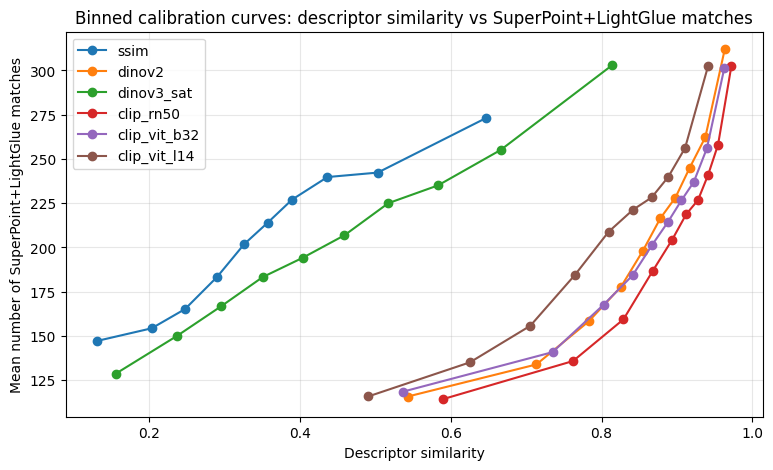

In [6]:
plt.figure(figsize=(9, 5))

for metric in metrics:
    curve = curves_df[curves_df["metric"] == metric].copy()

    if curve.empty:
        print(f"WARNING: skipping '{metric}' because it has no valid binned curve")
        continue

    plt.plot(
        curve["mean_similarity"],
        curve["mean_sift_matches"],
        marker="o",
        label=metric,
    )

plt.xlabel("Descriptor similarity")
plt.ylabel("Mean number of SuperPoint+LightGlue matches")
plt.title("Binned calibration curves: descriptor similarity vs SuperPoint+LightGlue matches")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A good descriptor should produce a curve where higher similarity bins consistently have more SIFT matches.

So the best metric is the one with the most monotonic and steeply increasing curve.

Spearman correlation measures how well two variables are related by a monotonic relationship.

In this case, it answers: When descriptor similarity increases, does the number of SIFT matches also tend to increase?

It does not require the relationship to be linear. It only checks whether the ranking is consistent.

Intuition

Suppose you have image pairs with:

descriptor_similarity:  0.10, 0.40, 0.70, 0.90
sift_matches:             12,   80,  150,  240

Both variables increase together. Spearman correlation will be close to: +1

If higher descriptor similarity usually means fewer SIFT matches, Spearman will be close to: -1

If there is no consistent ordering, it will be close to: 0